In [1]:
from pathlib import Path
import pandas as pd
from pesco.io import load_sources, prepare_psd

from pesco.experimental.clustering import (
    compute_clusters,
    identify_small_clusters,
    get_no_peak,
)
from pesco.experimental.peak_testing import (
    cutintervals,
    test_lobes,
    test_regions,
)
from pesco.experimental.plotting import (
    plot_clusters,
    plot_histogram,
    plot_lobes,
    plot_regions,
)

seed = 3

In [2]:
PROJECT_DIR = Path("/Users/daniel/PhD/spectral-comparison/code/")

DATA_PATH_SOURCES = Path(f"{PROJECT_DIR}/data/Mantini2018")

DATA_PATH_IEEG = Path(f"{PROJECT_DIR}/data/Frauscher2018")  # TODO: fill in

matfile = DATA_PATH_IEEG / "WakefulnessMatlabFile.mat"
region_dict_file = DATA_PATH_IEEG / "RegionInformation.csv"


Creating RawArray with float64 data, n_channels=1444, n_times=62689
    Range : 0 ... 62688 =      0.000 ...   313.440 secs
Ready.
source PSD segment: 126.7-186.7 s
auto no-peak candidates: []; using: None
derived 21 intervals (paper: 22)


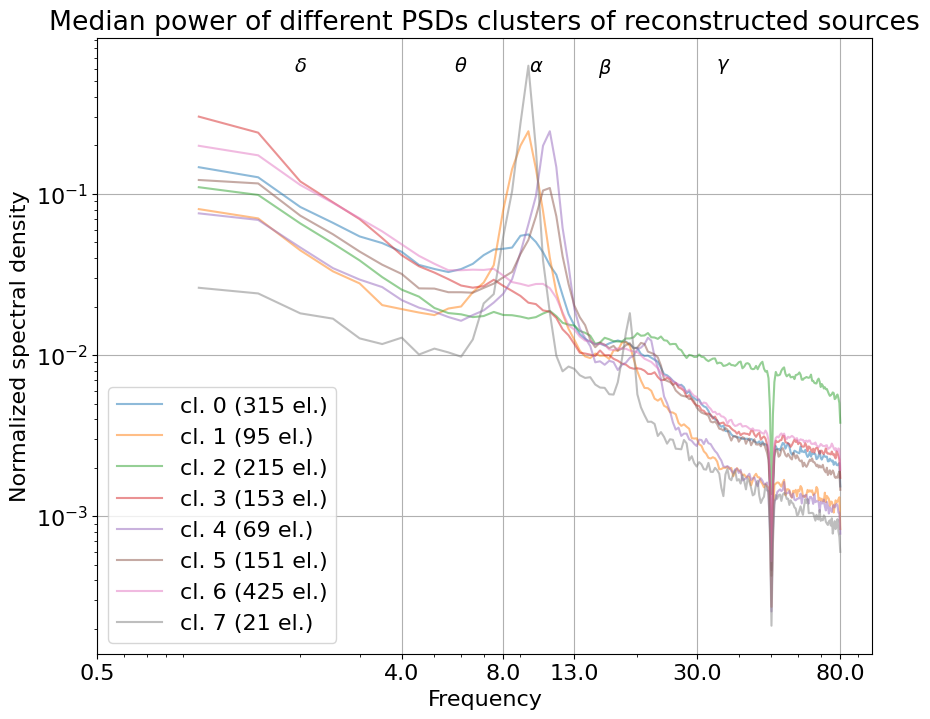

In [4]:
from pesco.preprocess import compute_psd, normalize_psd
from pesco.experimental.clustering import (
    compute_clusters, identify_small_clusters, get_no_peak,
)
from pesco.experimental.peak_testing import cutintervals, compute_intervals, test_lobes
from pesco.experimental.plotting import (
    plot_clusters, plot_histogram, plot_lobes,
)

# Sources
dataset = "reconstructed sources"
NO_PEAK_SUMMARY = "mean"
PLOT_SUMMARY = "median"
SOURCE_DURATION_SECONDS = 60.0
SOURCE_START_SECONDS = None # None uses the centered 60 s segment; set manually after QC if needed
FREQ_RANGE = (1, 80.0)
USE_FRAUSCHER_BINS = True
USE_FRAUSCHER_BINS = False
N_PEAKS = 8 
SOURCE_NO_PEAK_CLUSTER = None  # None: no source no-peak baseline; "auto": Frauscher criterion; int: force cluster

raw_src, result = load_sources(DATA_PATH_SOURCES)
source_n_samples = int(SOURCE_DURATION_SECONDS * raw_src.info["sfreq"])
if source_n_samples > raw_src.n_times:
    raise ValueError("Source recording is shorter than SOURCE_DURATION_SECONDS.")

if SOURCE_START_SECONDS is None:
    source_start = (raw_src.n_times - source_n_samples) // 2
else:
    source_start = int(SOURCE_START_SECONDS * raw_src.info["sfreq"])
source_stop = source_start + source_n_samples
if source_start < 0 or source_stop > raw_src.n_times:
    raise ValueError("Requested source PSD segment falls outside the recording.")

print(
    f"source PSD segment: {source_start / raw_src.info['sfreq']:.1f}"
    f"-{source_stop / raw_src.info['sfreq']:.1f} s"
)
source_data = raw_src.get_data(start=source_start, stop=source_stop)

f, psd_source = compute_psd(
    source_data, raw_src.info["sfreq"],
    fmin=FREQ_RANGE[0], fmax=FREQ_RANGE[1],
)
psd_source = normalize_psd(psd_source, f)

psd_source_df = pd.DataFrame(psd_source, index=raw_src.info["ch_names"], columns=f)

Y = psd_source_df.join(result)

# Stage 2: cluster
psd_clust = compute_clusters(
    Y.drop(["Region name", "Lobe", "region_number", "dataset"], axis=1),
    n_clusters=N_PEAKS, random_seed=seed,
)
auto_smal = identify_small_clusters(psd_clust, summary=NO_PEAK_SUMMARY)
if SOURCE_NO_PEAK_CLUSTER == "auto":
    smal = auto_smal
elif SOURCE_NO_PEAK_CLUSTER is None:
    smal = []
else:
    smal = [int(SOURCE_NO_PEAK_CLUSTER)]
print(f"auto no-peak candidates: {auto_smal}; using: {smal or None}")
no_peak_df, _ = get_no_peak(psd_clust, smal, summary=NO_PEAK_SUMMARY)

# Stage 3: bin and test
if USE_FRAUSCHER_BINS:
    colbin, _ = cutintervals(f)
else:
    # Previous source-derived adaptive bins:
    # edges = compute_intervals(f, psd_source.mean(axis=0), threshold=0.04)
    # print(f"derived {len(edges) - 1} intervals (paper: 22)")
    # colbin, _ = cutintervals(f, edges=edges)
    edges = compute_intervals(f, psd_source.mean(axis=0), threshold=0.04)
    print(f"derived {len(edges) - 1} intervals (paper: 22)")
    colbin, _ = cutintervals(f, edges=edges)
psd = Y.drop(["region_number", "dataset"], axis=1)
sig_lobes = test_lobes(no_peak_df, psd, colbin)

# Stage 4: plot
#plot_clusters(psd_clust, f, dataset, smal, nopeak=smal[0] if smal else None, summary=PLOT_SUMMARY, log_y=True)
plot_sources = plot_clusters(psd_clust, f, dataset, smal, nopeak=smal[0] if smal else None, summary=PLOT_SUMMARY, log_y=True)



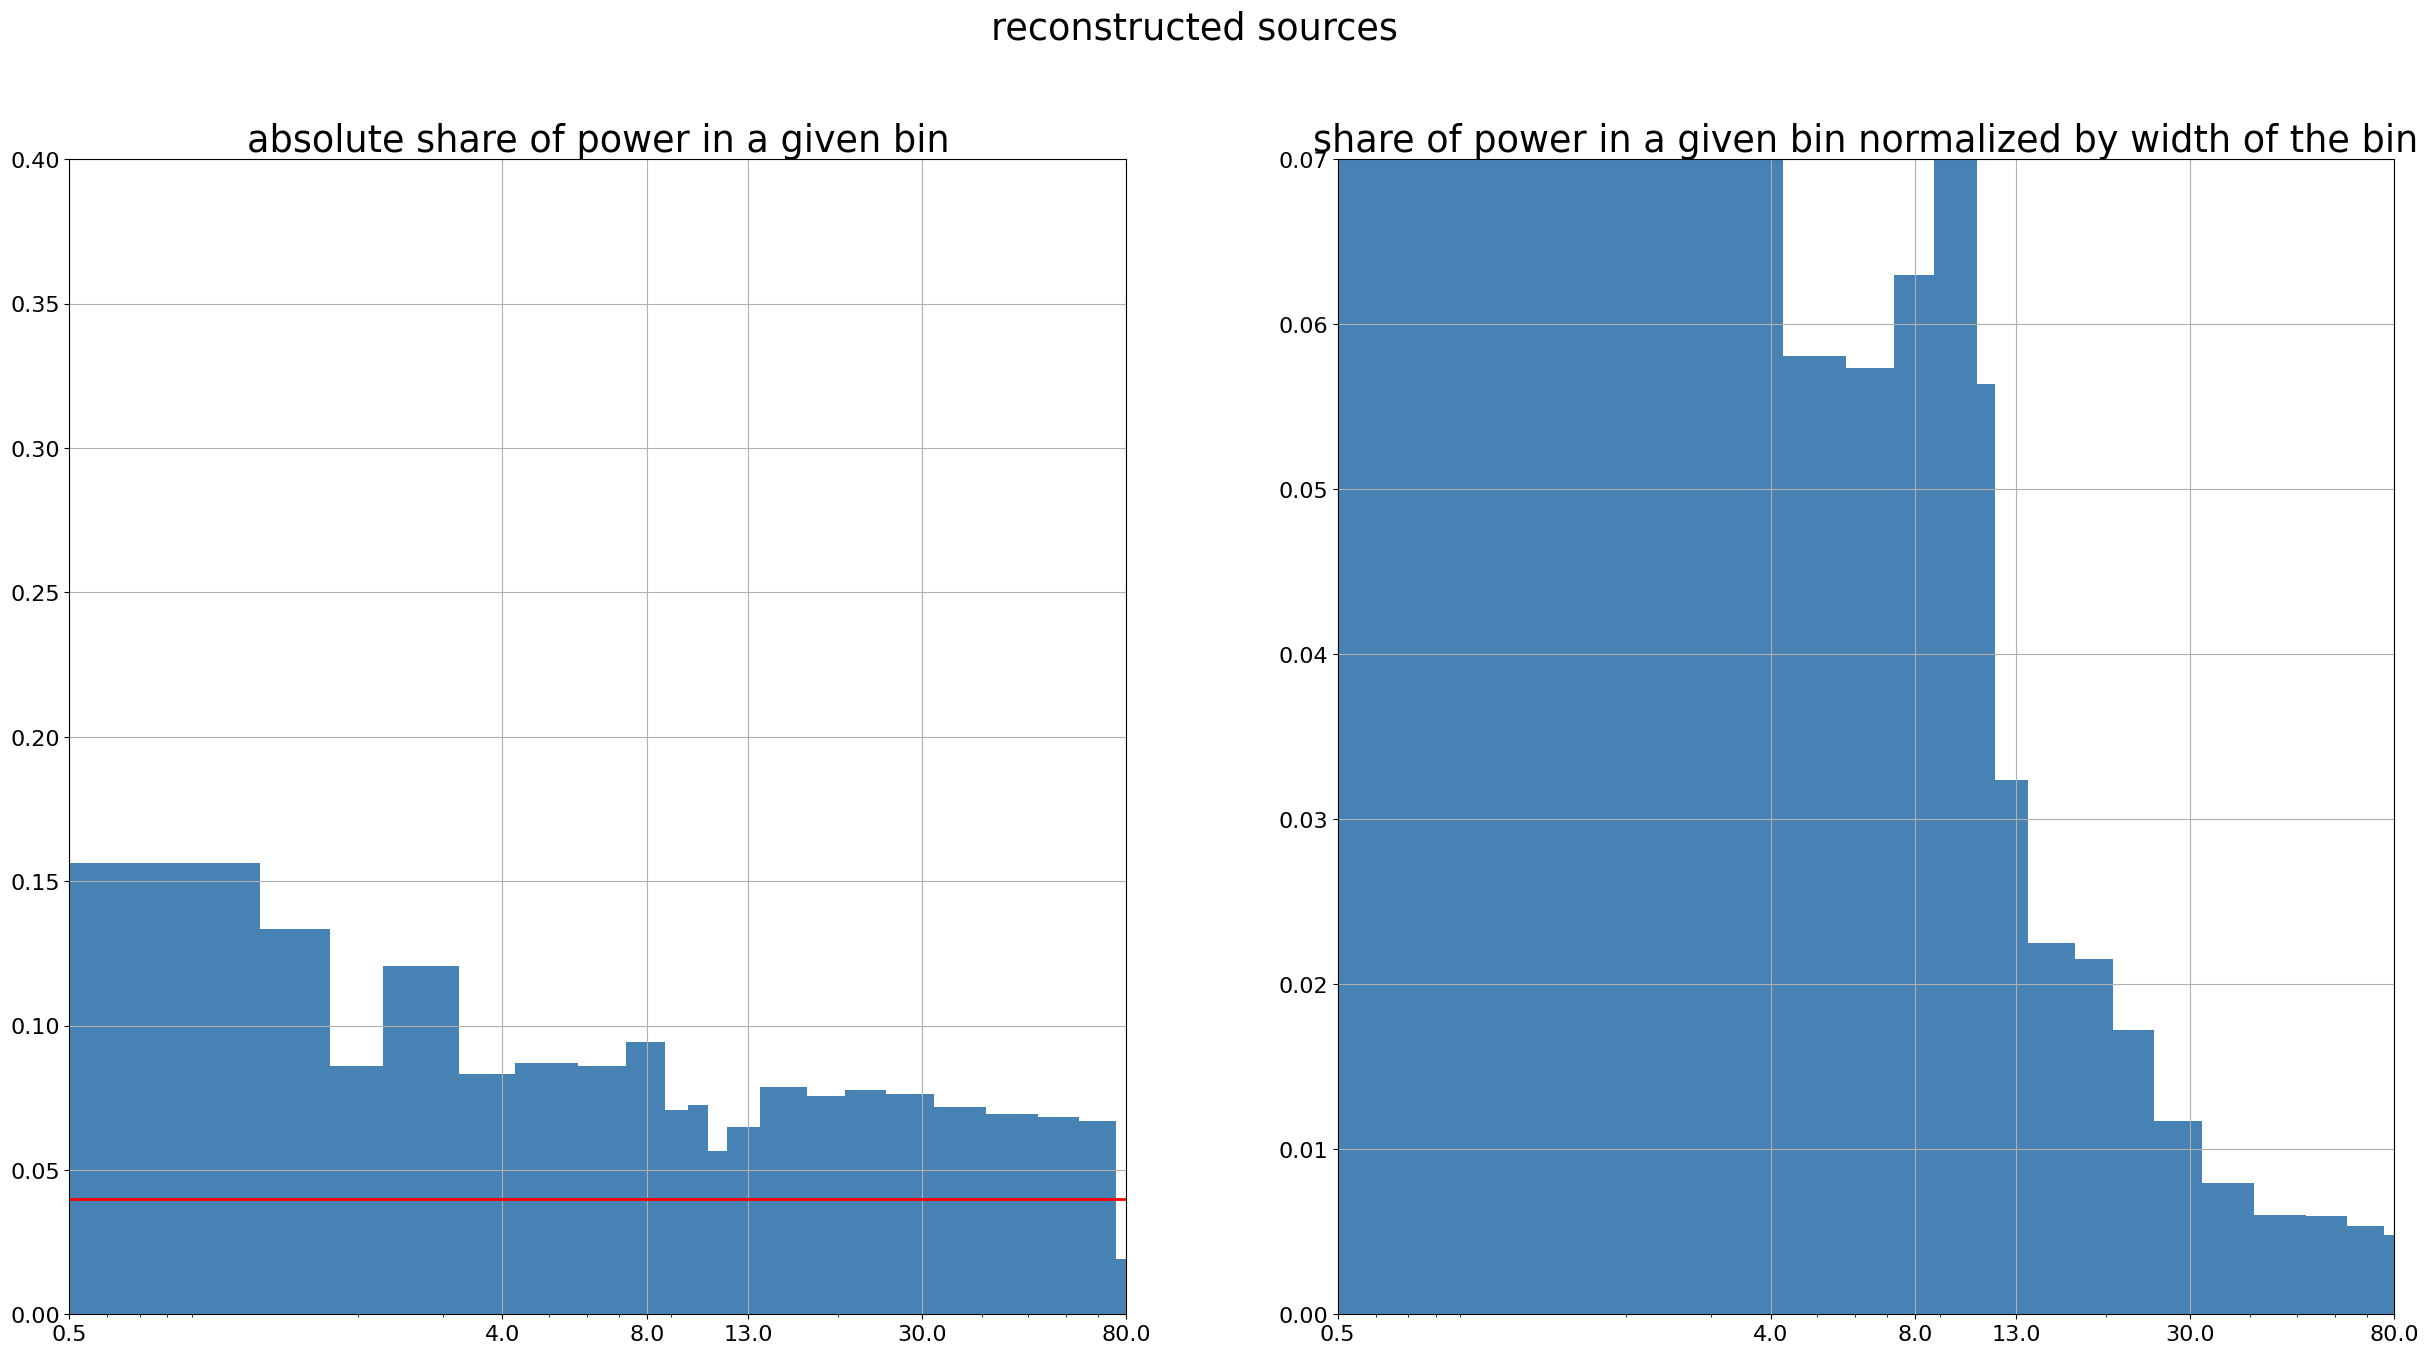

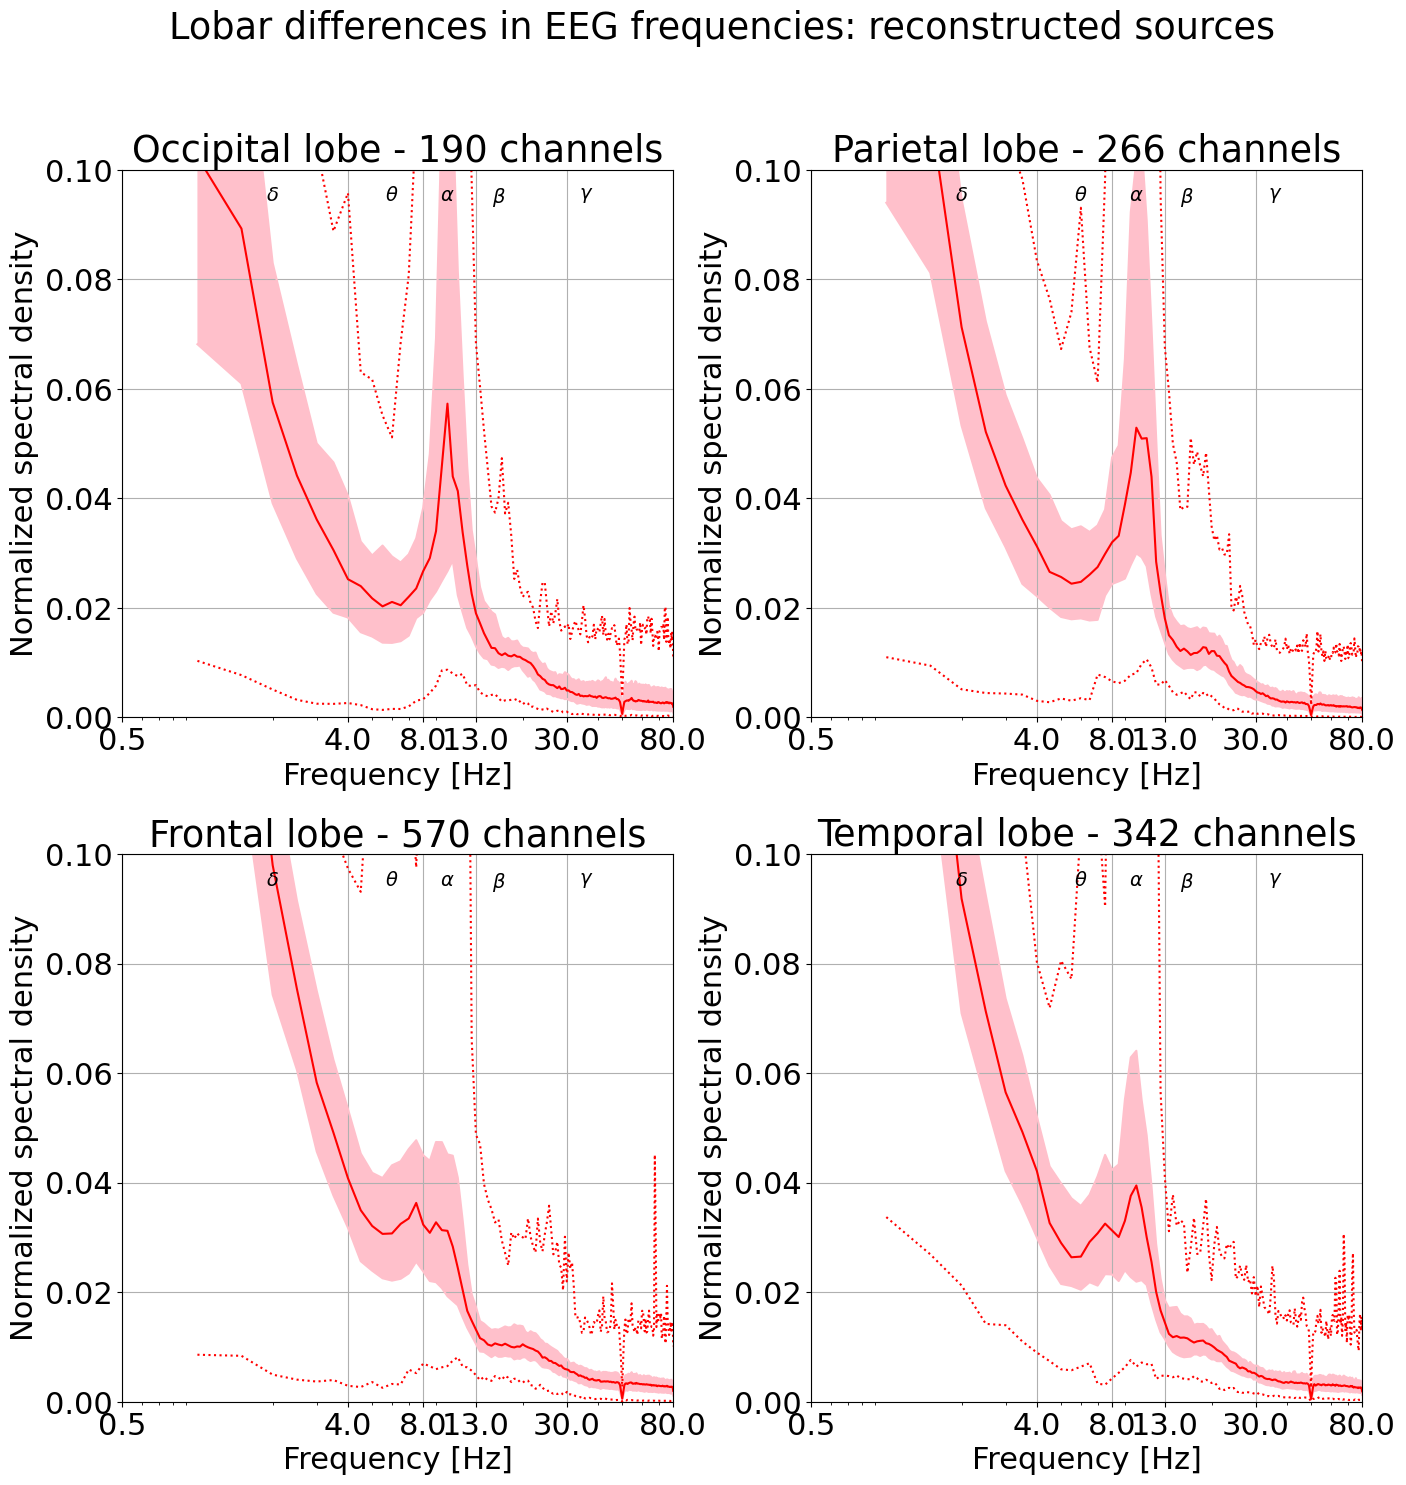

In [ ]:
plot_histogram(psd, colbin, dataset, summary=PLOT_SUMMARY)
plot_lobes(psd_clust, psd, f, smal, dataset, sig_lobes, show=True, summary=PLOT_SUMMARY)